# Plan

- Define the constants and parameters for the analysis
- Model the system and shots etc first before anything. Write a function to create all the models, test them all and store in a pkl for any test being done with any shots etc. 
- Just get all the results in first for all of the datasets, error bars, CI etc can be found later without need to change the code initially

Things to test in the function
- Shot sweep with all models to find fidelity for both pure and mixed states
- Do this with 2 qubits and 3 qubits (can be determined from which dataset is used)
- Measure runtime for all methods (Stokes, MLE, NNs [testing runtime])

In [7]:
# Define global constants and parameters
HIDDEN_SIZES = (256, 256, 256)
LEARNING_RATE = 5e-4
BATCH_SIZE = 64
EPOCHS = 100
DROPOUT = 0.08

In [8]:
# import all files
import os

files = sorted(os.listdir("data"))
test_files = [f for f in files if "_test" in f]
train_test_pairs = [(f.replace("_test", "_train"), f) for f in test_files]

In [9]:
# define a function to ascertain key info from the filename
def parse_filename(filename):
    parts = filename.split("_")
    number_qubits = int(parts[0].replace("q", ""))
    state_type = parts[1]
    num_shots = int(parts[2].replace("shots", ""))
    return number_qubits, state_type, num_shots

In [10]:
import numpy as np
# Check if a state is physical
def is_physical(rho):
    # Check if the matrix is Hermitian
    if not np.allclose(rho, rho.conj().T):
        return False
    
    # Check if the matrix is positive semi-definite
    eigenvals = np.linalg.eigvalsh(rho)
    if  np.any(eigenvals < -1e-8):
        return False
    
    # Check if the matrix is normalized
    if not np.isclose(np.trace(rho), 1.0):
        return False
    
    return True

In [11]:
# define a function to take one train test pair and run the full training and evaluation process, returning the history and final output
import QST_core_processes as qst
import pickle
import time

def run_full_process(train_file, test_file):

    # parse the filename to get key info
    number_qubits, state_type, num_shots = parse_filename(test_file)

    results = {
        "dataset_info": train_file.replace("_train", ""),
        "qubits": number_qubits,
        "state_type": state_type,
        "shots": num_shots,
        "outputs": {}
    }
    
    # load the data
    data_train = np.load(os.path.join("data", train_file), allow_pickle=True)
    data_test = np.load(os.path.join("data", test_file), allow_pickle=True)

    def fidelities_vs_truth(pred_rhos):
        return np.array([qst.fidelity(data_test['rhos'][k], pred_rhos[k]) for k in range(len(data_test['rhos']))])
    
    # Stokes data

    start = time.time()
    rhos = qst.stokes_reconstruct_dataset(
            P = data_train['P'],
            counts = data_test['counts'],
            shots = data_test['shots'],
            n_qubits = number_qubits
        )
    end = time.time()
    stokes_time = end - start

    results["outputs"]["Stokes"] = {
        "rhos": rhos,
        "fidelities": fidelities_vs_truth(rhos),
        "fraction_physical": np.mean([is_physical(rho) for rho in rhos]),
        "time": stokes_time
    }

    # MLE data

    start = time.time()
    rhos = qst.mle_reconstruct_dataset(
            P = data_train['P'],
            counts = data_test['counts'],
            n_qubits = number_qubits,
            steps=200
        )
    end = time.time()
    mle_time = end - start

    results["outputs"]["MLE"] = {
        "rhos": rhos,
        "fidelities": fidelities_vs_truth(rhos),
        "fraction_physical": np.mean([is_physical(rho) for rho in rhos]),
        "time": mle_time
    }

    # Naive Data

    nn_naive = qst.NN_Builder(
        n_qubits = number_qubits,
        model_type = "mlp",
        loss_type = "mse",
        target = "rho",
        hidden_sizes = HIDDEN_SIZES,
        dropout = DROPOUT,
        lr = LEARNING_RATE,
        batch_size = BATCH_SIZE,
        epochs = EPOCHS
    )

    _, prediction, eval_time = nn_naive.fit_and_predict(data_train, data_test)

    results["outputs"]["Naive_NN"] = {
        "rhos": prediction,
        "fidelities": fidelities_vs_truth(prediction),
        "fraction_physical": np.mean([is_physical(rho) for rho in prediction]),
        "time": eval_time
    }

    # Physics Informed Data

    nn_physics = qst.NN_Builder(
        n_qubits = number_qubits,
        model_type = "mlp",
        loss_type = "fidelity",
        target = "tau",
        hidden_sizes = HIDDEN_SIZES,
        dropout = DROPOUT,
        lr = LEARNING_RATE,
        batch_size = BATCH_SIZE,
        epochs = EPOCHS
    )

    _, prediction, eval_time = nn_physics.fit_and_predict(data_train, data_test)

    results["outputs"]["Physics_Informed_NN"] = {
        "rhos": prediction,
        "fidelities": fidelities_vs_truth(prediction),
        "fraction_physical": np.mean([is_physical(rho) for rho in prediction]),
        "time": eval_time
    }

    if number_qubits == 2:

        # Basic CNN data

        nn_cnn = qst.NN_Builder(
            n_qubits = number_qubits,
            model_type = "cnn",
            loss_type = "fidelity",
            target = "tau",
            hidden_sizes = HIDDEN_SIZES,
            dropout = DROPOUT,
            cnn_channels = (8, 16),
            cnn_kernel_size = 3,
            lr = LEARNING_RATE,
            batch_size = BATCH_SIZE,
            epochs = EPOCHS
        )

        _, prediction, eval_time = nn_cnn.fit_and_predict(data_train, data_test)

        results["outputs"]["CNN"] = {
            "rhos": prediction,
            "fidelities": fidelities_vs_truth(prediction),
            "fraction_physical": np.mean([is_physical(rho) for rho in prediction]),
            "time": eval_time
        }

        # CNN_overlap_mixing data

        nn_cnn_overlap = qst.NN_Builder(
            n_qubits = number_qubits,
            model_type = "cnn",
            loss_type = "fidelity",
            target = "tau",
            hidden_sizes = HIDDEN_SIZES,
            dropout = DROPOUT,
            cnn_channels = (8, 16),
            cnn_kernel_size = 3,
            cnn_kernel_type = "proj_kernel",
            proj_kernel_metric = "overlap",
            lr = LEARNING_RATE,
            batch_size = BATCH_SIZE,
            epochs = EPOCHS
        )

        _, prediction, eval_time = nn_cnn_overlap.fit_and_predict(data_train, data_test)

        results["outputs"]["CNN_Overlap_Mixing"] = {
            "rhos": prediction,
            "fidelities": fidelities_vs_truth(prediction),
            "fraction_physical": np.mean([is_physical(rho) for rho in prediction]),
            "time": eval_time
        }

        # CNN_fidelity_mixing data

        nn_cnn_fidelity = qst.NN_Builder(
            n_qubits = number_qubits,
            model_type = "cnn",
            loss_type = "fidelity",
            target = "tau",
            hidden_sizes = HIDDEN_SIZES,
            dropout = DROPOUT,
            cnn_channels = (8, 16),
            cnn_kernel_size = 3,
            cnn_kernel_type = "proj_kernel",
            proj_kernel_metric = "fidelity",
            lr = LEARNING_RATE,
            batch_size = BATCH_SIZE,
            epochs = EPOCHS
        )

        _, prediction, eval_time = nn_cnn_fidelity.fit_and_predict(data_train, data_test)

        results["outputs"]["CNN_Fidelity_Mixing"] = {
            "rhos": prediction,
            "fidelities": fidelities_vs_truth(prediction),
            "fraction_physical": np.mean([is_physical(rho) for rho in prediction]),
            "time": eval_time
        }

        # CNN_graph_mixing data

        nn_cnn_graph = qst.NN_Builder(
            n_qubits = number_qubits,
            model_type = "cnn",
            loss_type = "fidelity",
            target = "tau",
            hidden_sizes = HIDDEN_SIZES,
            dropout = DROPOUT,
            cnn_channels = (8, 16),
            cnn_kernel_size = 3,
            cnn_kernel_type = "proj_graph",
            proj_kernel_metric = "fidelity",
            lr = LEARNING_RATE,
            batch_size = BATCH_SIZE,
            epochs = EPOCHS
        )

        _, prediction, eval_time = nn_cnn_graph.fit_and_predict(data_train, data_test)

        results["outputs"]["CNN_Graph_Mixing"] = {
            "rhos": prediction,
            "fidelities": fidelities_vs_truth(prediction),
            "fraction_physical": np.mean([is_physical(rho) for rho in prediction]),
            "time": eval_time
        }

    return results

In [12]:
all_results = []
run = 1

for train_file, test_file in train_test_pairs:
    print(f"Running set {run} out of {len(train_test_pairs)}")
    results = run_full_process(train_file, test_file)
    all_results.append(results)
    run += 1

    # Save results to a file
    with open(f"all_results.pkl", "wb") as f:
        pickle.dump(all_results, f)


Running set 1 out of 32
Running set 2 out of 32
Running set 3 out of 32
Running set 4 out of 32
Running set 5 out of 32
Running set 6 out of 32
Running set 7 out of 32
Running set 8 out of 32
Running set 9 out of 32
Running set 10 out of 32
Running set 11 out of 32
Running set 12 out of 32
Running set 13 out of 32
Running set 14 out of 32
Running set 15 out of 32
Running set 16 out of 32
Running set 17 out of 32
Running set 18 out of 32
Running set 19 out of 32
Running set 20 out of 32
Running set 21 out of 32
Running set 22 out of 32
Running set 23 out of 32
Running set 24 out of 32
Running set 25 out of 32
Running set 26 out of 32
Running set 27 out of 32
Running set 28 out of 32
Running set 29 out of 32
Running set 30 out of 32
Running set 31 out of 32
Running set 32 out of 32


In [ ]:
print("ALL DONE!!")

ALL DONE!!


# Analysing the Results

In [2]:
import pickle
results = pickle.load(open("all_results.pkl", "rb"))

#### Layout of the data

Results is a list, where each element is a dictionary for one train test dataset with the following keys: dict_keys(['dataset_info', 'qubits', 'state_type', 'shots', 'outputs']). Outputs contains all of the methods as keys (['Stokes', 'MLE', 'Naive_NN', 'Physics_Informed_NN', 'CNN', 'CNN_Overlap_Mixing', 'CNN_Fidelity_Mixing', 'CNN_Graph_Mixing']), and within each of these is further info as their keys: ['rhos', 'fidelities', 'fraction_physical', 'time']. This is the layout of the full pickle across the 32 train test data sets.

As far as graphs to produce in the analysis, I'm considering showing Stokes and MLE performance first (in the methodology), then in the results showing:
- how the naive NN and physics informed NN compete (both fidelity performance and the fraction of physical states given)
- how the physics informed NN performs against Stokes and MLE in:
    - performance (fidelity)
    - time taken (MLE should suffer)
    - fraction of physical states predicted (Stokes should suffer)
- I also want to show the CNNs against the standard NN to compare these, ruling out CNNs as a viable option
- How Stokes MLE and physics informed NN perform with a 3 qubit system (performance time and physciality again)

There will obviously be other diagrams but for the results does that cover it?

In [2]:
results[0].keys()

dict_keys(['dataset_info', 'qubits', 'state_type', 'shots', 'outputs'])

Graphs to produce (all graphs involving means can have standard error included [over 1000 states]):

Stokes vs MLE - classical baseline: fidelity vs number of shots, include line for pure states and mixed states

Naive NN vs Physics informed: fidelity vs shots, also include fractional physicality (phys informed will win).

Phys inf vs CNNs: fidelity comparison for all CNN variants (show not beneficial and explain in discussion)

Phys inf. vs classical methods (main research question): fidelity vs shots for 2 qubit, runtime vs shots, fraction of physical states per shot
Phys inf vs classical methods histogram: showcase the distribution of fidelities too for robustness.
See whether mixed and pure should be together or seperate

Scale to 3 qubits: fidelity, runtime, physicality for classical and phys inf. NN


Focus around 3 questions: can NNs produce physical density matrices reliably, can they match recosntruction fidelity (t test), do they offer advantages


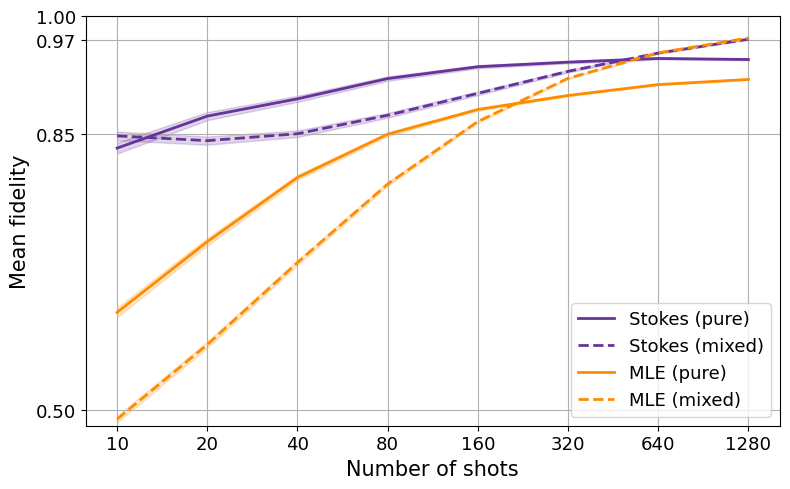

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ------------------------------------------------------------
# Aggregate 2-qubit results for Stokes and MLE
# ------------------------------------------------------------
methods_to_plot = ["Stokes", "MLE"]
target_qubits = 2

# Store fidelities grouped by (method, state_type, shots)
grouped = defaultdict(list)

for entry in results:
    if int(entry["qubits"]) != target_qubits:
        continue

    state_type = entry["state_type"].strip().lower()
    shots = int(entry["shots"])

    for method in methods_to_plot:
        if method in entry["outputs"]:
            fidelities = np.asarray(entry["outputs"][method]["fidelities"], dtype=float)
            grouped[(method, state_type, shots)].extend(fidelities.tolist())

# ------------------------------------------------------------
# Compute mean and standard error
# ------------------------------------------------------------
summary = {}

for key, vals in grouped.items():
    vals = np.asarray(vals, dtype=float)
    mean = np.mean(vals)
    se = np.std(vals, ddof=1) / np.sqrt(len(vals))
    summary[key] = {
        "mean": mean,
        "se": se,
        "n": len(vals)
    }

# ------------------------------------------------------------
# Organise for plotting
# ------------------------------------------------------------
state_types = ["pure", "mixed"]
colours = {
    "Stokes": "rebeccapurple",
    "MLE": "darkorange",
    "Naive_NN": "dodgerblue",
    "Physics_Informed_NN": "forestgreen"
}
linestyles = {
    "pure": "-",
    "mixed": "--"
}

plt.figure(figsize=(8, 5))

for method in methods_to_plot:
    for state_type in state_types:
        # Get all shot values available for this method/state_type
        shot_vals = sorted(
            shots for (m, s, shots) in summary.keys()
            if m == method and s == state_type
        )

        if not shot_vals:
            continue

        means = np.array([summary[(method, state_type, shots)]["mean"] for shots in shot_vals])
        ses = np.array([summary[(method, state_type, shots)]["se"] for shots in shot_vals])

        label = f"{method} ({state_type})"

        plt.plot(
            shot_vals,
            means,
            label=label,
            color=colours[method],
            linestyle=linestyles[state_type],
            linewidth=2
        )

        plt.fill_between(
            shot_vals,
            means - ses,
            means + ses,
            color=colours[method],
            alpha=0.2
        )

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------
plt.xlabel("Number of shots", size=15)
plt.ylabel("Mean fidelity", size=15)
# plt.title("Stokes vs MLE for 2-qubit states")
plt.legend(fontsize=13)
plt.ylim(0.48, 1)
plt.xscale("log", base=2)
shot_ticks = [10, 20, 40, 80, 160, 320, 640, 1280]
plt.xticks(shot_ticks, size=13)
plt.yticks([0.5, 0.85, 0.97, 1])
plt.yticks(size=13)
plt.gca().xaxis.set_major_formatter(plt.ScalarFormatter())
plt.grid(True, which='both')
plt.tight_layout()
# plt.savefig("stokes_vs_mle_fidelity.png", dpi=600)
plt.show()

Error sleeves are present just too small to be visible - also the tail end of MLE has been cut off for better visibiltiy

/var/folders/fx/lnm0r8px7dl3hm8pdd5ryl4w0000gn/T/ipykernel_5110/4197426402.py:209: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


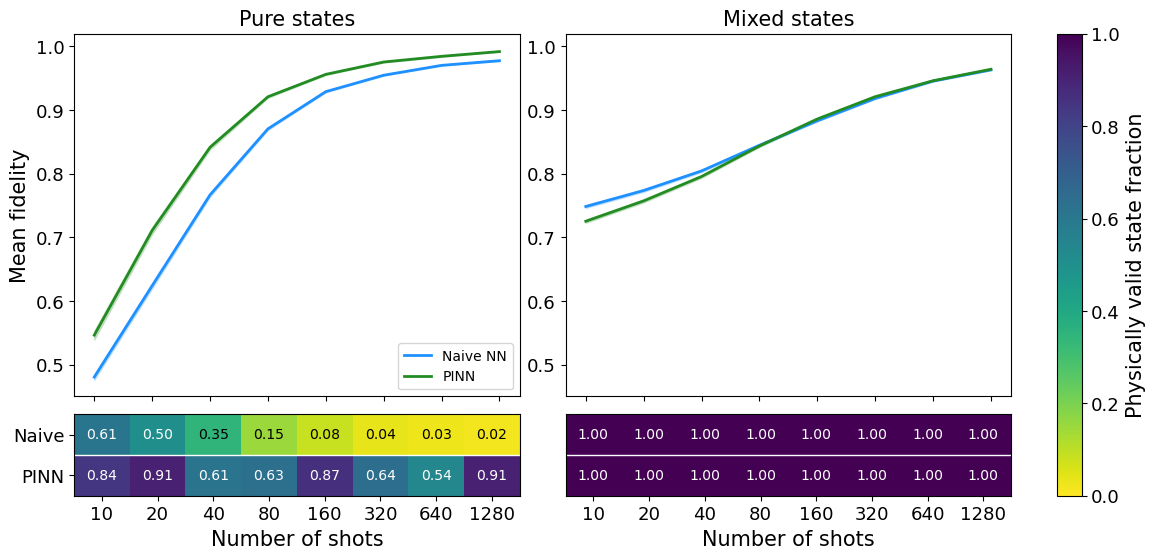

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

methods = ["Naive_NN", "Physics_Informed_NN"]
state_types = ["pure", "mixed"]
target_qubits = 2
shot_ticks = [10, 20, 40, 80, 160, 320, 640, 1280]

colours = {
    "Naive_NN": "dodgerblue",
    "Physics_Informed_NN": "forestgreen"
}

linestyles = {
    "Naive_NN": "-",
    "Physics_Informed_NN": "-"
}

display_names = {
    "Naive_NN": "Naive NN",
    "Physics_Informed_NN": "PINN"
}

plt.rcParams.update({
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13
})

# ------------------------------------------------------------
# Collect data
# ------------------------------------------------------------
fidelity_data = {}
physical_data = {}

for entry in results:
    if int(entry["qubits"]) != target_qubits:
        continue

    state_type = entry["state_type"].strip().lower()
    if state_type not in state_types:
        continue

    shots = int(entry["shots"])

    for method in methods:
        if method not in entry["outputs"]:
            continue

        key = (method, state_type, shots)

        fidelities = np.asarray(entry["outputs"][method]["fidelities"], dtype=float)
        fraction_physical = float(entry["outputs"][method]["fraction_physical"])

        if key not in fidelity_data:
            fidelity_data[key] = []
        fidelity_data[key].extend(fidelities.tolist())

        if key not in physical_data:
            physical_data[key] = []
        physical_data[key].append(fraction_physical)

# ------------------------------------------------------------
# Compute summary statistics
# ------------------------------------------------------------
fidelity_summary = {}
physical_summary = {}

for key, vals in fidelity_data.items():
    vals = np.asarray(vals, dtype=float)
    fidelity_summary[key] = {
        "mean": np.mean(vals),
        "se": np.std(vals, ddof=1) / np.sqrt(len(vals))
    }

for key, vals in physical_data.items():
    vals = np.asarray(vals, dtype=float)
    physical_summary[key] = {
        "mean": np.mean(vals)
    }

# ------------------------------------------------------------
# Figure layout
# ------------------------------------------------------------
fig = plt.figure(figsize=(13, 6))
outer = gridspec.GridSpec(
    2, 3,
    width_ratios=[1, 1, 0.055],
    height_ratios=[4, 0.9],
    wspace=0.15,
    hspace=0.08
)

norm = Normalize(vmin=0.0, vmax=1.0)
cmap = plt.cm.viridis_r

# Shared y-axis for fidelity plots
ax_main_left = fig.add_subplot(outer[0, 0])
ax_main_right = fig.add_subplot(outer[0, 1], sharey=ax_main_left)

main_axes = [ax_main_left, ax_main_right]
strip_axes = []

for col, (ax_main, state_type) in enumerate(zip(main_axes, state_types)):
    ax_strip = fig.add_subplot(outer[1, col])
    strip_axes.append(ax_strip)

    # --------------------------------------------------------
    # Fidelity lines on true log2 shot axis
    # --------------------------------------------------------
    for method in methods:
        shot_vals = sorted([
            shots for (m, s, shots) in fidelity_summary.keys()
            if m == method and s == state_type
        ])

        if not shot_vals:
            continue

        means = np.array([fidelity_summary[(method, state_type, s)]["mean"] for s in shot_vals])
        ses = np.array([fidelity_summary[(method, state_type, s)]["se"] for s in shot_vals])

        ax_main.plot(
            shot_vals,
            means,
            color=colours[method],
            linestyle=linestyles[method],
            linewidth=2,
            label=display_names[method]
        )

        ax_main.fill_between(
            shot_vals,
            means - ses,
            means + ses,
            color=colours[method],
            alpha=0.2
        )

    ax_main.set_title(f"{state_type.capitalize()} states", size=15)
    ax_main.set_ylabel("Mean fidelity")
    ax_main.set_xscale("log", base=2)
    ax_main.set_xticks(shot_ticks)
    ax_main.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax_main.tick_params(axis="x", labelbottom=False)

    # --------------------------------------------------------
    # Physicality strip on categorical axis
    # --------------------------------------------------------
    heat = np.full((2, len(shot_ticks)), np.nan)

    for i, method in enumerate(methods):
        for j, shots in enumerate(shot_ticks):
            key = (method, state_type, shots)
            if key in physical_summary:
                heat[i, j] = physical_summary[key]["mean"]

    im = ax_strip.imshow(
        heat,
        aspect="auto",
        cmap=cmap,
        norm=norm,
        interpolation="nearest"
    )

    ax_strip.set_yticks([0, 1])
    ax_strip.set_yticklabels(["Naive", "PINN"])
    if col == 1:  # right-hand heatmap
        ax_strip.set_yticks([])
        ax_strip.set_ylabel("")
    ax_strip.set_xticks(np.arange(len(shot_ticks)))
    ax_strip.set_xticklabels(shot_ticks)
    ax_strip.set_xlabel("Number of shots")

    # Cell separator between the two method rows
    ax_strip.hlines([0.5], xmin=-0.5, xmax=len(shot_ticks) - 0.5, colors="white", linewidth=1.0)

    # Annotate values
    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            val = heat[i, j]
            if not np.isnan(val):
                txt_colour = "white" if val > 0.5 else "black"
                ax_strip.text(
                    j, i, f"{val:.2f}",
                    ha="center", va="center",
                    fontsize=10, color=txt_colour
                )

# ------------------------------------------------------------
# Shared formatting
# ------------------------------------------------------------
ax_main_left.set_ylim(0.45, 1.02)
ax_main_left.legend(loc="lower right")

# Hide duplicate y-label on right fidelity panel if desired
ax_main_right.set_ylabel("")

cax = fig.add_subplot(outer[:, 2])
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("Physically valid state fraction")

# fig.suptitle("Naive vs Physics-Informed Neural Networks for 2-Qubit States", y=0.98)
plt.tight_layout()
plt.savefig("nn_comparison_fidelity_physicality.png", dpi=600)
plt.show()

/var/folders/fx/lnm0r8px7dl3hm8pdd5ryl4w0000gn/T/ipykernel_5110/3566951747.py:215: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


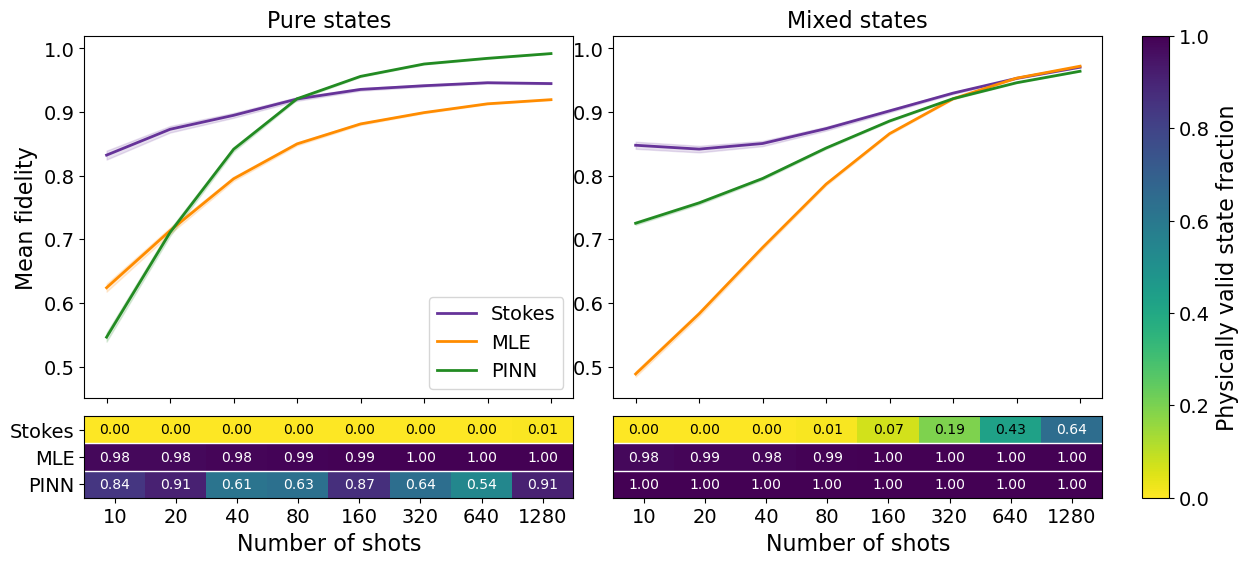

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

methods = ["Stokes", "MLE", "Physics_Informed_NN"]
state_types = ["pure", "mixed"]
target_qubits = 2
shot_ticks = [10, 20, 40, 80, 160, 320, 640, 1280]

plt.rcParams.update({
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14
})

colours = {
    "Stokes": "rebeccapurple",
    "MLE": "darkorange",
    "Physics_Informed_NN": "forestgreen"
}

linestyles = {
    "Stokes": "-",
    "MLE": "-",
    "Physics_Informed_NN": "-"
}

display_names = {
    "Stokes": "Stokes",
    "MLE": "MLE",
    "Physics_Informed_NN": "PINN"
}

# ------------------------------------------------------------
# Collect data
# ------------------------------------------------------------
fidelity_data = {}
physical_data = {}

for entry in results:
    if int(entry["qubits"]) != target_qubits:
        continue

    state_type = entry["state_type"].strip().lower()
    if state_type not in state_types:
        continue

    shots = int(entry["shots"])

    for method in methods:
        if method not in entry["outputs"]:
            continue

        key = (method, state_type, shots)

        fidelities = np.asarray(entry["outputs"][method]["fidelities"], dtype=float)
        fraction_physical = float(entry["outputs"][method]["fraction_physical"])

        if key not in fidelity_data:
            fidelity_data[key] = []
        fidelity_data[key].extend(fidelities.tolist())

        if key not in physical_data:
            physical_data[key] = []
        physical_data[key].append(fraction_physical)

# ------------------------------------------------------------
# Compute summary statistics
# ------------------------------------------------------------
fidelity_summary = {}
physical_summary = {}

for key, vals in fidelity_data.items():
    vals = np.asarray(vals, dtype=float)
    fidelity_summary[key] = {
        "mean": np.mean(vals),
        "se": np.std(vals, ddof=1) / np.sqrt(len(vals))
    }

for key, vals in physical_data.items():
    vals = np.asarray(vals, dtype=float)
    physical_summary[key] = {
        "mean": np.mean(vals)
    }

# ------------------------------------------------------------
# Figure layout
# ------------------------------------------------------------
fig = plt.figure(figsize=(14, 6))
outer = gridspec.GridSpec(
    2, 3,
    width_ratios=[1, 1, 0.055],
    height_ratios=[4, 0.9],
    wspace=0.12,
    hspace=0.08
)

norm = Normalize(vmin=0.0, vmax=1.0)
cmap = plt.cm.viridis_r

# Shared y-axis for fidelity plots
ax_main_left = fig.add_subplot(outer[0, 0])
ax_main_right = fig.add_subplot(outer[0, 1], sharey=ax_main_left)

main_axes = [ax_main_left, ax_main_right]
strip_axes = []

for col, (ax_main, state_type) in enumerate(zip(main_axes, state_types)):
    ax_strip = fig.add_subplot(outer[1, col])
    strip_axes.append(ax_strip)

    # --------------------------------------------------------
    # Fidelity lines on true log2 shot axis
    # --------------------------------------------------------
    for method in methods:
        shot_vals = sorted([
            shots for (m, s, shots) in fidelity_summary.keys()
            if m == method and s == state_type
        ])

        if not shot_vals:
            continue

        means = np.array([fidelity_summary[(method, state_type, s)]["mean"] for s in shot_vals])
        ses = np.array([fidelity_summary[(method, state_type, s)]["se"] for s in shot_vals])

        ax_main.plot(
            shot_vals,
            means,
            color=colours[method],
            linestyle=linestyles[method],
            linewidth=2,
            label=display_names[method]
        )

        ax_main.fill_between(
            shot_vals,
            means - ses,
            means + ses,
            color=colours[method],
            alpha=0.15
        )

    ax_main.set_title(f"{state_type.capitalize()} states", size=16)
    ax_main.set_ylabel("Mean fidelity")
    ax_main.set_xscale("log", base=2)
    ax_main.set_xticks(shot_ticks)
    ax_main.grid(False)
    ax_main.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax_main.tick_params(axis="x", labelbottom=False)

    # --------------------------------------------------------
    # Physicality strip on categorical axis
    # --------------------------------------------------------
    heat = np.full((len(methods), len(shot_ticks)), np.nan)

    for i, method in enumerate(methods):
        for j, shots in enumerate(shot_ticks):
            key = (method, state_type, shots)
            if key in physical_summary:
                heat[i, j] = physical_summary[key]["mean"]

    im = ax_strip.imshow(
        heat,
        aspect="auto",
        cmap=cmap,
        norm=norm,
        interpolation="nearest"
    )

    ax_strip.set_yticks(np.arange(len(methods)))
    ax_strip.set_yticklabels(["Stokes", "MLE", "PINN"])
    if col == 1:  # right-hand heatmap
        ax_strip.set_yticks([])
        ax_strip.set_ylabel("")
    ax_strip.set_xticks(np.arange(len(shot_ticks)))
    ax_strip.set_xticklabels(shot_ticks)
    ax_strip.grid(False)
    ax_strip.set_xlabel("Number of shots")

    # Cell separators
    for y in np.arange(0.5, len(methods) - 0.5, 1):
        ax_strip.hlines(y, xmin=-0.5, xmax=len(shot_ticks) - 0.5, colors="white", linewidth=1.0)

    # Annotate values
    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            val = heat[i, j]
            if not np.isnan(val):
                txt_colour = "white" if val > 0.5 else "black"
                ax_strip.text(
                    j, i, f"{val:.2f}",
                    ha="center", va="center",
                    fontsize=10, color=txt_colour
                )

# ------------------------------------------------------------
# Shared formatting
# ------------------------------------------------------------
ax_main_left.set_ylim(0.45, 1.02)
ax_main_left.legend(loc="lower right", fontsize=14)

# Hide duplicate y-label on right fidelity panel
ax_main_right.set_ylabel("")

cax = fig.add_subplot(outer[:, 2])
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("Physically valid state fraction")

# fig.suptitle("Stokes, MLE, and Physics-Informed Neural Network for 2-Qubit States", y=0.98)
plt.tight_layout()
plt.savefig("stokes_mle_nn_comparison_fidelity_physicality.png", dpi=600)
plt.show()

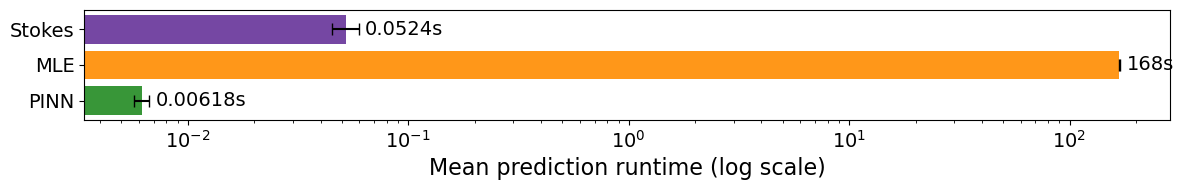

In [6]:
import numpy as np
import matplotlib.pyplot as plt

methods = ["Stokes", "MLE", "Physics_Informed_NN"]

colours = {
    "Stokes": "rebeccapurple",
    "MLE": "darkorange",
    "Physics_Informed_NN": "forestgreen"
}

display_names = {
    "Stokes": "Stokes",
    "MLE": "MLE",
    "Physics_Informed_NN": "PINN"
}

plt.rcParams.update({
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14
})

# ------------------------------------------------------------
# Collect runtimes across all relevant runs
# ------------------------------------------------------------
runtime_data = {method: [] for method in methods}

for entry in results:
    if int(entry["qubits"]) != 2:
        continue

    for method in methods:
        if method in entry["outputs"]:
            runtime_data[method].append(float(entry["outputs"][method]["time"]))

# ------------------------------------------------------------
# Compute mean runtime and standard error
# ------------------------------------------------------------
means = []
ses = []
labels = []

for method in methods:
    vals = np.asarray(runtime_data[method], dtype=float)
    means.append(np.mean(vals))
    ses.append(np.std(vals, ddof=1) / np.sqrt(len(vals)))
    labels.append(display_names[method])

means = np.array(means)
ses = np.array(ses)

# ------------------------------------------------------------
# Plot horizontal bar chart
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 2))

y_pos = np.arange(len(methods))

ax.barh(
    y_pos,
    means,
    xerr=ses,
    color=[colours[m] for m in methods],
    alpha=0.9,
    capsize=4
)

for i, (mean, se) in enumerate(zip(means, ses)):
    ax.text(
        mean * 1.07 + se,            # place slightly to the right of the bar
        i,
        f"{mean:.3g}s",         # format runtime
        va="center",
        fontsize=14
    )

ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_xscale("log")
ax.set_xticks([0.01, 0.1, 1, 10, 100])
ax.set_xlabel("Mean prediction runtime (log scale)")

# Put first method at top
ax.invert_yaxis()

plt.tight_layout()
plt.grid(False)
plt.savefig("method_runtime_comparison.png", dpi=600)
plt.show()

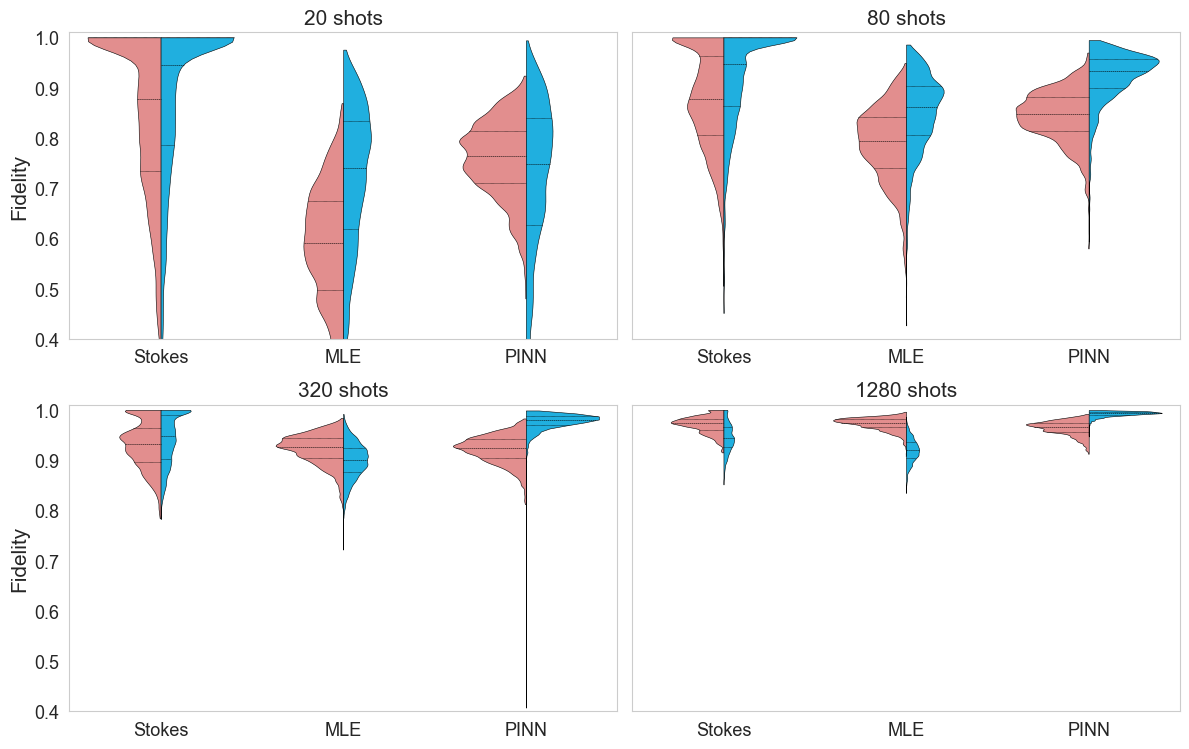

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams.update({
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13
})

# ------------------------------------------------------------
# Configuration (easy to change)
# ------------------------------------------------------------

shots_to_plot = [20, 80, 320, 1280]
y_limits = (0.4, 1.01)   # change this easily if needed

methods = ["Stokes", "MLE", "Physics_Informed_NN"]

method_names = {
    "Stokes": "Stokes",
    "MLE": "MLE",
    "Physics_Informed_NN": "PINN"
}

palette = {
    "pure": "deepskyblue",
    "mixed": "lightcoral"
}

# ------------------------------------------------------------
# Extract fidelity data
# ------------------------------------------------------------

rows = []

for entry in results:

    if int(entry["qubits"]) != 2:
        continue

    state_type = entry["state_type"].strip().lower()
    shots = int(entry["shots"])

    if shots not in shots_to_plot:
        continue

    for method in methods:

        fidelities = entry["outputs"][method]["fidelities"]

        for f in fidelities:
            rows.append({
                "method": method_names[method],
                "state_type": state_type,
                "shots": shots,
                "fidelity": f
            })

df = pd.DataFrame(rows)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

sns.set_style("whitegrid")

fig, axes = plt.subplots(
    2, 2,
    figsize=(12,8),
    sharey=True
)

axes = axes.flatten()

for ax, shot in zip(axes, shots_to_plot):

    df_shot = df[df["shots"] == shot]

    sns.violinplot(
        data=df_shot,
        x="method",
        y="fidelity",
        hue="state_type",
        split=True,
        inner="quartile",
        palette=palette,
        cut=0,
        bw_method=0.15,
        ax=ax,
        linecolor="black",
        linewidth=0.4
        
    )

    ax.set_title(f"{shot} shots", size=15)
    ax.grid(False)
    ax.set_xlabel("")
    ax.set_ylabel("Fidelity")
    ax.set_ylim(y_limits)

    # remove repeated legends
    ax.legend_.remove()

# ------------------------------------------------------------
# Single shared legend
# ------------------------------------------------------------

handles, labels = axes[0].get_legend_handles_labels()

# fig.legend(
#     handles,
#     labels,
#     title="State type",
#     loc="upper center",
#     ncol=2,
#     frameon=False
# )

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig("fidelity_violin_plots.png", dpi=600)
plt.show()

In [21]:
import pandas as pd

summary_rows = []

for (method, state_type, shots), group in df.groupby(["method", "state_type", "shots"]):
    
    fidelities = group["fidelity"]
    
    summary_rows.append({
        "method": method,
        "state_type": state_type,
        "shots": shots,
        
        # Core stats
        "mean": fidelities.mean(),
        "median": fidelities.median(),
        "std": fidelities.std(),
        
        # Quartiles
        "q1": fidelities.quantile(0.25),
        "q3": fidelities.quantile(0.75),
        "iqr": fidelities.quantile(0.75) - fidelities.quantile(0.25),
        
        # Shape indicators
        "min": fidelities.min(),
        "max": fidelities.max(),
        
        # Skewness (very useful)
        "skew": fidelities.skew(),
        
        # Tail behaviour
        "low_outliers_frac": (fidelities < fidelities.quantile(0.1)).mean(),
        "high_outliers_frac": (fidelities > fidelities.quantile(0.9)).mean()
    })

summary_df = pd.DataFrame(summary_rows)

# Sort nicely for readability
summary_df = summary_df.sort_values(["state_type", "shots", "method"])

summary_df

,method,state_type,shots,mean,median,std,q1,q3,iqr,min,max,skew,low_outliers_frac,high_outliers_frac
0,MLE,mixed,20,0.582949,0.591011,0.125484,0.497320,0.674328,0.177008,0.182203,0.869012,-0.370433,0.1,0.1
8,Physics-Informed NN,mixed,20,0.757254,0.763455,0.076410,0.709264,0.813246,0.103981,0.480263,0.923800,-0.450903,0.1,0.1
16,Stokes,mixed,20,0.841787,0.877490,0.162993,0.733153,1.000000,0.266847,0.239251,1.000000,-0.907642,0.1,0.0
1,MLE,mixed,80,0.786723,0.792888,0.075250,0.739447,0.841102,0.101655,0.482300,0.949072,-0.562538,0.1,0.1
9,Physics-Informed NN,mixed,80,0.843492,0.846460,0.050476,0.813630,0.880667,0.067037,0.579800,0.969733,-0.549464,0.1,0.1
17,Stokes,mixed,80,0.873970,0.877995,0.097412,0.806595,0.962611,0.156016,0.505495,1.000000,-0.485642,0.1,0.0
2,MLE,mixed,320,0.920894,0.926357,0.032251,0.903234,0.944173,0.040939,0.721995,0.983876,-1.038334,0.1,0.1
10,Physics-Informed NN,mixed,320,0.921031,0.924552,0.028002,0.903391,0.941296,0.037905,0.812314,0.982857,-0.615789,0.1,0.1
18,Stokes,mixed,320,0.929790,0.932995,0.047015,0.896930,0.963135,0.066206,0.784484,1.000000,-0.360068,0.1,0.1
3,MLE,mixed,1280,0.972105,0.974699,0.012586,0.965347,0.981237,0.015890,0.908122,0.996248,-1.091535,0.1,0.1


Truncated at 0.4 for clarity, extends lower in 20 shots

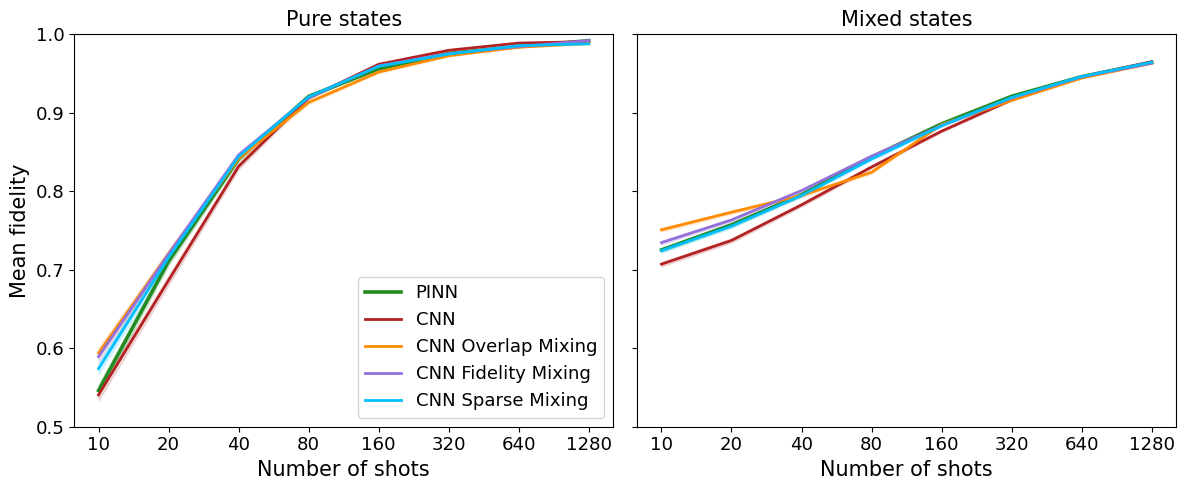

In [7]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13
})

methods = [
    "Physics_Informed_NN",
    "CNN",
    "CNN_Overlap_Mixing",
    "CNN_Fidelity_Mixing",
    "CNN_Graph_Mixing"
]

state_types = ["pure", "mixed"]
target_qubits = 2
shot_ticks = [10, 20, 40, 80, 160, 320, 640, 1280]

colours = {
    "Physics_Informed_NN": "forestgreen",
    "CNN": "firebrick",
    "CNN_Overlap_Mixing": "darkorange",
    "CNN_Fidelity_Mixing": "mediumpurple",
    "CNN_Graph_Mixing": "deepskyblue"
}

display_names = {
    "Physics_Informed_NN": "PINN",
    "CNN": "CNN",
    "CNN_Overlap_Mixing": "CNN Overlap Mixing",
    "CNN_Fidelity_Mixing": "CNN Fidelity Mixing",
    "CNN_Graph_Mixing": "CNN Sparse Mixing"
}

line_widths = {
    "Physics_Informed_NN": 2.6,
    "CNN": 2.0,
    "CNN_Overlap_Mixing": 2.0,
    "CNN_Fidelity_Mixing": 2.0,
    "CNN_Graph_Mixing": 2.0
}

# ------------------------------------------------------------
# Collect fidelity data
# ------------------------------------------------------------
fidelity_data = {}

for entry in results:
    if int(entry["qubits"]) != target_qubits:
        continue

    state_type = entry["state_type"].strip().lower()
    if state_type not in state_types:
        continue

    shots = int(entry["shots"])

    for method in methods:
        if method not in entry["outputs"]:
            continue

        key = (method, state_type, shots)
        fidelities = np.asarray(entry["outputs"][method]["fidelities"], dtype=float)

        if key not in fidelity_data:
            fidelity_data[key] = []

        fidelity_data[key].extend(fidelities.tolist())

# ------------------------------------------------------------
# Compute mean fidelity and standard error
# ------------------------------------------------------------
fidelity_summary = {}

for key, vals in fidelity_data.items():
    vals = np.asarray(vals, dtype=float)
    fidelity_summary[key] = {
        "mean": np.mean(vals),
        "se": np.std(vals, ddof=1) / np.sqrt(len(vals)),
        "n": len(vals)
    }

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, state_type in zip(axes, state_types):
    for method in methods:
        shot_vals = sorted([
            shots for (m, s, shots) in fidelity_summary.keys()
            if m == method and s == state_type
        ])

        if not shot_vals:
            continue

        means = np.array([fidelity_summary[(method, state_type, s)]["mean"] for s in shot_vals])
        ses = np.array([fidelity_summary[(method, state_type, s)]["se"] for s in shot_vals])

        ax.plot(
            shot_vals,
            means,
            color=colours[method],
            linewidth=line_widths[method],
            label=display_names[method]
        )

        ax.fill_between(
            shot_vals,
            means - ses,
            means + ses,
            color=colours[method],
            alpha=0.15
        )

    ax.set_title(f"{state_type.capitalize()} states", size=15)
    ax.set_xlabel("Number of shots")
    ax.set_xscale("log", base=2)
    ax.set_xticks(shot_ticks)
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.grid(False)

axes[0].set_ylabel("Mean fidelity")
axes[0].set_ylim(0.5, 1)
axes[0].set_yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
axes[0].set_yticklabels(["0.5", "0.6", "0.7", "0.8", "0.9", "1.0"])
axes[0].legend(loc="lower right", fontsize=13)

plt.tight_layout()
plt.savefig("nn_cnn_comparison_fidelity.png", dpi=600)
plt.show()

at high shots, no benefit. But at lower shots, CNN overlap mixing performs better than physics informed

In [21]:
import pandas as pd
import numpy as np

# --------------------------------
# MODELS TO COMPARE
# --------------------------------
MODELS = [
    "Physics_Informed_NN",
    "CNN_Overlap_Mixing",
    "CNN_Fidelity_Mixing",
    "CNN_Graph_Mixing",
    "CNN"
]

# --------------------------------
# 1. Flatten results into dataframe
# --------------------------------
rows = []

for entry in results:

    state_type = entry["state_type"]
    shots = entry["shots"]
    qubits = entry["qubits"]

    for model_name, model_data in entry["outputs"].items():

        if model_name not in MODELS:
            continue

        fidelities = model_data["fidelities"]

        rows.append({
            "qubits": qubits,
            "state_type": state_type,
            "shots": shots,
            "model": model_name,
            "mean_fidelity": np.mean(fidelities),
            "std_fidelity": np.std(fidelities),
            "median_fidelity": np.median(fidelities),
            "fraction_physical": model_data["fraction_physical"],
            "runtime": model_data["time"]
        })

df = pd.DataFrame(rows)

print("\nFlattened dataframe:")
print(df.head())

# --------------------------------
# 2. Pivot to compare models
# --------------------------------
comparison = df.pivot_table(
    index=["qubits", "state_type", "shots"],
    columns="model",
    values="mean_fidelity"
).reset_index()

print("\nMean fidelity comparison:")
print(comparison)

# --------------------------------
# 3. Pairwise differences
# --------------------------------
comparison["Overlap_minus_PhysInf"] = (
    comparison["CNN_Overlap_Mixing"] - comparison["Physics_Informed_NN"]
)

comparison["FidelityMix_minus_PhysInf"] = (
    comparison["CNN_Fidelity_Mixing"] - comparison["Physics_Informed_NN"]
)

comparison["Overlap_minus_FidelityMix"] = (
    comparison["CNN_Overlap_Mixing"] - comparison["CNN_Fidelity_Mixing"]
)

comparison["Graph_minus_PhysInf"] = (
    comparison["CNN_Graph_Mixing"] - comparison["Physics_Informed_NN"]
)

comparison["Graph_minus_Overlap"] = (
    comparison["CNN_Graph_Mixing"] - comparison["CNN_Overlap_Mixing"]
)

comparison["Graph_minus_FidelityMix"] = (
    comparison["CNN_Graph_Mixing"] - comparison["CNN_Fidelity_Mixing"]
)

comparison["CNN_minus_PhysInf"] = (
    comparison["CNN"] - comparison["Physics_Informed_NN"]
)

comparison["CNN_minus_Overlap"] = (
    comparison["CNN"] - comparison["CNN_Overlap_Mixing"]
)

comparison["CNN_minus_FidelityMix"] = (
    comparison["CNN"] - comparison["CNN_Fidelity_Mixing"]
)

# --------------------------------
# 4. Determine winner per shot
# --------------------------------
comparison["winner"] = comparison[
    ["Physics_Informed_NN", "CNN_Overlap_Mixing", "CNN_Fidelity_Mixing", "CNN_Graph_Mixing", "CNN"]
].idxmax(axis=1)

print("\nWinner per condition:")
print(comparison[[
    "qubits",
    "state_type",
    "shots",
    "Physics_Informed_NN",
    "CNN_Overlap_Mixing",
    "CNN_Fidelity_Mixing",
    "CNN_Graph_Mixing",
    "CNN",
    "winner"
]])

# --------------------------------
# 5. Overall summary
# --------------------------------
summary = (
    comparison
    .groupby("state_type")["winner"]
    .value_counts()
    .unstack(fill_value=0)
)

print("\nWin counts per state type:")
print(summary)

# --------------------------------
# 6. Mean advantage of each model
# --------------------------------
mean_scores = (
    df.groupby(["state_type", "model"])["mean_fidelity"]
    .mean()
    .unstack()
)

print("\nAverage fidelity by model:")
print(mean_scores)

# --------------------------------
# Optional: save for inspection
# --------------------------------
comparison.to_csv("cnn_architecture_comparison.csv", index=False)


Flattened dataframe:
   qubits state_type  shots                model  mean_fidelity  std_fidelity  \
0       2      mixed     10  Physics_Informed_NN       0.725256      0.079660   
1       2      mixed     10                  CNN       0.707142      0.090281   
2       2      mixed     10   CNN_Overlap_Mixing       0.750928      0.070914   
3       2      mixed     10  CNN_Fidelity_Mixing       0.734565      0.079596   
4       2      mixed     10     CNN_Graph_Mixing       0.724475      0.081401   

   median_fidelity  fraction_physical   runtime  
0         0.728902                1.0  0.007755  
1         0.711915                1.0  0.016488  
2         0.754780                1.0  0.013206  
3         0.743939                1.0  0.013627  
4         0.729761                1.0  0.018941  

Mean fidelity comparison:
model  qubits state_type  shots       CNN  CNN_Fidelity_Mixing  \
0           2      mixed     10  0.707142             0.734565   
1           2      mixed     20 

In [22]:
# t test showing whether CNN should be used (significantly different mean fidelity) for 2 qubits

import pandas as pd
from scipy.stats import ttest_rel

# Load CSV produced earlier
df = pd.read_csv("cnn_architecture_comparison.csv")

# Keep only 2-qubit data
df = df[df["qubits"] == 2]

# Extract vectors
phys = df["Physics_Informed_NN"]
overlap = df["CNN_Overlap_Mixing"]
fidelity = df["CNN_Fidelity_Mixing"]
graph = df["CNN_Graph_Mixing"]
cnn = df["CNN"]

# Paired t-tests
t_overlap, p_overlap = ttest_rel(overlap, phys)
t_fidelity, p_fidelity = ttest_rel(fidelity, phys)
t_graph, p_graph = ttest_rel(graph, phys)
t_cnn, p_cnn = ttest_rel(cnn, phys)

print("Paired comparison: CNN Overlap Mixing vs Physics-Informed NN")
print("Mean improvement:", (overlap - phys).mean())
print("t-statistic:", t_overlap)
print("p-value:", p_overlap)
print()

print("Paired comparison: CNN Fidelity Mixing vs Physics-Informed NN")
print("Mean improvement:", (fidelity - phys).mean())
print("t-statistic:", t_fidelity)
print("p-value:", p_fidelity)
print()

print("Paired comparison: CNN Graph Mixing vs Physics-Informed NN")
print("Mean improvement:", (graph - phys).mean())
print("t-statistic:", t_graph)
print("p-value:", p_graph)
print()

print("Paired comparison: CNN vs Physics-Informed NN")
print("Mean improvement:", (cnn - phys).mean())
print("t-statistic:", t_cnn)
print("p-value:", p_cnn)

Paired comparison: CNN Overlap Mixing vs Physics-Informed NN
Mean improvement: 0.003203205854773933
t-statistic: 0.8249393676586529
p-value: 0.42233159129686293

Paired comparison: CNN Fidelity Mixing vs Physics-Informed NN
Mean improvement: 0.0047313821297447975
t-statistic: 1.7315465247849349
p-value: 0.10386298149036303

Paired comparison: CNN Graph Mixing vs Physics-Informed NN
Mean improvement: 0.0015693499322759347
t-statistic: 0.8529770555159997
p-value: 0.40708659510750933

Paired comparison: CNN vs Physics-Informed NN
Mean improvement: -0.0065313416760878346
t-statistic: -2.858176043231075
p-value: 0.011966869820562638


Use t tests in report - also explain in report the maths of a t test

/var/folders/fx/lnm0r8px7dl3hm8pdd5ryl4w0000gn/T/ipykernel_5110/2401307179.py:215: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


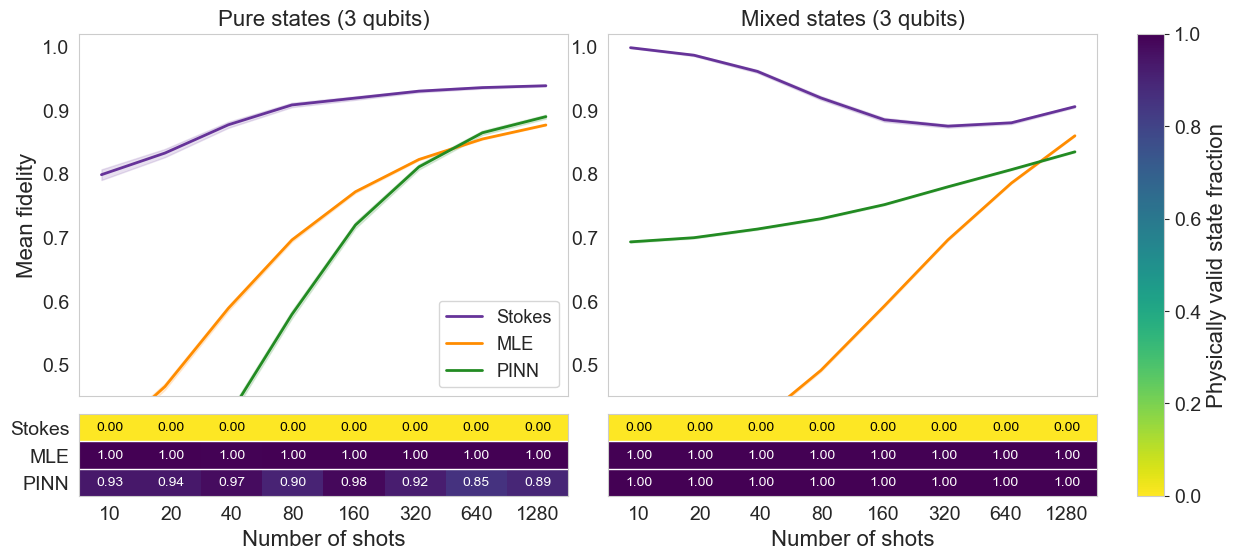

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

methods = ["Stokes", "MLE", "Physics_Informed_NN"]
state_types = ["pure", "mixed"]
target_qubits = 3
shot_ticks = [10, 20, 40, 80, 160, 320, 640, 1280]

colours = {
    "Stokes": "rebeccapurple",
    "MLE": "darkorange",
    "Physics_Informed_NN": "forestgreen"
}

linestyles = {
    "Stokes": "-",
    "MLE": "-",
    "Physics_Informed_NN": "-"
}

display_names = {
    "Stokes": "Stokes",
    "MLE": "MLE",
    "Physics_Informed_NN": "PINN"
}

plt.rcParams.update({
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14
})

# ------------------------------------------------------------
# Collect data
# ------------------------------------------------------------
fidelity_data = {}
physical_data = {}

for entry in results:
    if int(entry["qubits"]) != target_qubits:
        continue

    state_type = entry["state_type"].strip().lower()
    if state_type not in state_types:
        continue

    shots = int(entry["shots"])

    for method in methods:
        if method not in entry["outputs"]:
            continue

        key = (method, state_type, shots)

        fidelities = np.asarray(entry["outputs"][method]["fidelities"], dtype=float)
        fraction_physical = float(entry["outputs"][method]["fraction_physical"])

        if key not in fidelity_data:
            fidelity_data[key] = []
        fidelity_data[key].extend(fidelities.tolist())

        if key not in physical_data:
            physical_data[key] = []
        physical_data[key].append(fraction_physical)

# ------------------------------------------------------------
# Compute summary statistics
# ------------------------------------------------------------
fidelity_summary = {}
physical_summary = {}

for key, vals in fidelity_data.items():
    vals = np.asarray(vals, dtype=float)
    fidelity_summary[key] = {
        "mean": np.mean(vals),
        "se": np.std(vals, ddof=1) / np.sqrt(len(vals))
    }

for key, vals in physical_data.items():
    vals = np.asarray(vals, dtype=float)
    physical_summary[key] = {
        "mean": np.mean(vals)
    }

# ------------------------------------------------------------
# Figure layout
# ------------------------------------------------------------
fig = plt.figure(figsize=(14, 6))
outer = gridspec.GridSpec(
    2, 3,
    width_ratios=[1, 1, 0.055],
    height_ratios=[4, 0.9],
    wspace=0.12,
    hspace=0.08
)

norm = Normalize(vmin=0.0, vmax=1.0)
cmap = plt.cm.viridis_r

# Shared y-axis for fidelity plots
ax_main_left = fig.add_subplot(outer[0, 0])
ax_main_right = fig.add_subplot(outer[0, 1], sharey=ax_main_left)

main_axes = [ax_main_left, ax_main_right]
strip_axes = []

for col, (ax_main, state_type) in enumerate(zip(main_axes, state_types)):
    ax_strip = fig.add_subplot(outer[1, col])
    strip_axes.append(ax_strip)

    # --------------------------------------------------------
    # Fidelity lines on true log2 shot axis
    # --------------------------------------------------------
    for method in methods:
        shot_vals = sorted([
            shots for (m, s, shots) in fidelity_summary.keys()
            if m == method and s == state_type
        ])

        if not shot_vals:
            continue

        means = np.array([fidelity_summary[(method, state_type, s)]["mean"] for s in shot_vals])
        ses = np.array([fidelity_summary[(method, state_type, s)]["se"] for s in shot_vals])

        ax_main.plot(
            shot_vals,
            means,
            color=colours[method],
            linestyle=linestyles[method],
            linewidth=2,
            label=display_names[method]
        )

        ax_main.fill_between(
            shot_vals,
            means - ses,
            means + ses,
            color=colours[method],
            alpha=0.15
        )

    ax_main.set_title(f"{state_type.capitalize()} states (3 qubits)", size=16)
    ax_main.set_ylabel("Mean fidelity")
    ax_main.set_xscale("log", base=2)
    ax_main.set_xticks(shot_ticks)
    ax_main.grid(False)
    ax_main.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax_main.tick_params(axis="x", labelbottom=False)

    # --------------------------------------------------------
    # Physicality strip on categorical axis
    # --------------------------------------------------------
    heat = np.full((len(methods), len(shot_ticks)), np.nan)

    for i, method in enumerate(methods):
        for j, shots in enumerate(shot_ticks):
            key = (method, state_type, shots)
            if key in physical_summary:
                heat[i, j] = physical_summary[key]["mean"]

    im = ax_strip.imshow(
        heat,
        aspect="auto",
        cmap=cmap,
        norm=norm,
        interpolation="nearest"
    )

    ax_strip.set_yticks(np.arange(len(methods)))
    ax_strip.set_yticklabels(["Stokes", "MLE", "PINN"])
    if col == 1:  # right-hand heatmap
        ax_strip.set_yticks([])
        ax_strip.set_ylabel("")
    ax_strip.set_xticks(np.arange(len(shot_ticks)))
    ax_strip.set_xticklabels(shot_ticks)
    ax_strip.grid(False)
    ax_strip.set_xlabel("Number of shots")

    # Cell separators
    for y in np.arange(0.5, len(methods) - 0.5, 1):
        ax_strip.hlines(y, xmin=-0.5, xmax=len(shot_ticks) - 0.5, colors="white", linewidth=1.0)

    # Annotate values
    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            val = heat[i, j]
            if not np.isnan(val):
                txt_colour = "white" if val > 0.5 else "black"
                ax_strip.text(
                    j, i, f"{val:.2f}",
                    ha="center", va="center",
                    fontsize=10, color=txt_colour
                )

# ------------------------------------------------------------
# Shared formatting
# ------------------------------------------------------------
ax_main_left.set_ylim(0.45, 1.02)
ax_main_left.legend(loc="lower right", fontsize=13)

# Hide duplicate y-label on right fidelity panel
ax_main_right.set_ylabel("")

cax = fig.add_subplot(outer[:, 2])
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("Physically valid state fraction")

# fig.suptitle("Stokes, MLE, and Physics-Informed Neural Network for 2-Qubit States", y=0.98)
plt.tight_layout()
plt.grid(False)
plt.savefig("stokes_mle_nn_comparison_fidelity_physicality_3qubit.png", dpi=600)
plt.show()

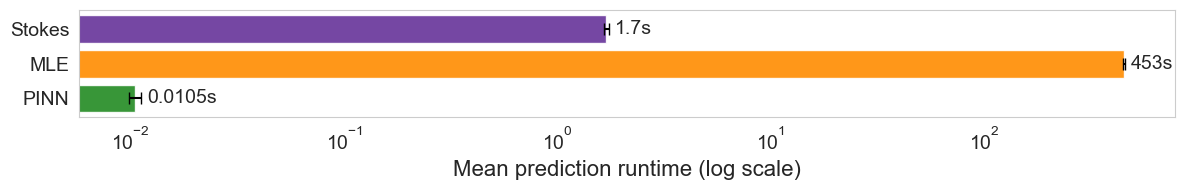

In [10]:
import numpy as np
import matplotlib.pyplot as plt

methods = ["Stokes", "MLE", "Physics_Informed_NN"]

colours = {
    "Stokes": "rebeccapurple",
    "MLE": "darkorange",
    "Physics_Informed_NN": "forestgreen"
}

display_names = {
    "Stokes": "Stokes",
    "MLE": "MLE",
    "Physics_Informed_NN": "PINN"
}

plt.rcParams.update({
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14
})

# ------------------------------------------------------------
# Collect runtimes across all relevant runs
# ------------------------------------------------------------
runtime_data = {method: [] for method in methods}

for entry in results:
    if int(entry["qubits"]) != 3:
        continue

    for method in methods:
        if method in entry["outputs"]:
            runtime_data[method].append(float(entry["outputs"][method]["time"]))

# ------------------------------------------------------------
# Compute mean runtime and standard error
# ------------------------------------------------------------
means = []
ses = []
labels = []

for method in methods:
    vals = np.asarray(runtime_data[method], dtype=float)
    means.append(np.mean(vals))
    ses.append(np.std(vals, ddof=1) / np.sqrt(len(vals)))
    labels.append(display_names[method])

means = np.array(means)
ses = np.array(ses)

# ------------------------------------------------------------
# Plot horizontal bar chart
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 2))

y_pos = np.arange(len(methods))

ax.barh(
    y_pos,
    means,
    xerr=ses,
    color=[colours[m] for m in methods],
    alpha=0.9,
    capsize=4
)

for i, (mean, se) in enumerate(zip(means, ses)):
    ax.text(
        mean * 1.07 + se,            # place slightly to the right of the bar
        i,
        f"{mean:.3g}s",         # format runtime
        va="center",
        fontsize=14
    )

ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_xscale("log")
ax.set_xlabel("Mean prediction runtime (log scale)")

# Put first method at top
ax.invert_yaxis()
ax.grid(False)

plt.tight_layout()
plt.savefig("method_runtime_comparison_3qubit.png", dpi=600)
plt.show()

# FIX BROKEN GRAPHS, CONSIDER SWAPPING OUT PHYSICS INFORMED FOR OVERLAP MIXING CNN